# 5 Výsledky a evaluace

Tento notebook navazuje na předzpracovaná data vytvořená v předchozí části práce.

Cílem notebooku je:

1. načíst předzpracované trénovací a testovací datasety,
2. definovat klasifikační modely a evaluační metriky,
3. stanovit baseline pro porovnání výsledků,
4. provést 27 experimentů napříč algoritmy, scénáři vyvážení a příznakovými sadami,
5. vytvořit souhrnnou výsledkovou tabulku pro porovnání modelů.

## 5.1 Metodika vyhodnocování a výběr metrik

Vzhledem k výrazné třídní nevyváženosti datasetu není vhodné hodnotit modely pouze pomocí celkové přesnosti. Accuracy může být zkreslena ve prospěch majoritní třídy a nemusí dostatečně odhalit slabý výkon modelu na minoritních třídách.

Z tohoto důvodu jsou v notebooku sledovány zejména metriky balanced accuracy, macro F1-score, Matthewsův korelační koeficient a Cohenovo kappa. Celková accuracy je uváděna pouze jako doplňková metrika pro základní orientaci.

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier

import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

In [2]:
OUTPUT_DIR = os.path.join("..", "outputs")
PREPROCESSED_DIR = os.path.join(OUTPUT_DIR, "preprocessed")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)


RANDOM_STATE = 42

FEATURE_SETS = ["basic", "extended", "advanced"]

BALANCING_STRATEGIES = [
    "algorithm_level",
    "data_level",
    "hybrid"
]

MODEL_NAMES = [
    "Logistic Regression",
    "SVM RBF",
    "Random Forest"
]

TARGET_COLUMN = "trida"

PORADI_TRID_EN = [
    "hungry",
    "discomfort",
    "tired",
    "belly_pain",
    "burping"
]

TRIDA_MAP_CZ = {
    "hungry": "hlad",
    "discomfort": "nepohodlí",
    "tired": "únava",
    "belly_pain": "bolest břicha",
    "burping": "říhání"
}

## 5.2 Načtení předzpracovaných dat

Každá kombinace příznakové sady a scénáře vyvážení má vlastní trénovací a testovací soubor uložený ve složce `outputs/preprocessed`. Testovací množina zůstává pro danou příznakovou sadu stejná, zatímco trénovací množina se liší podle použité strategie práce s nevyvážeností.

In [3]:
def load_preprocessed_dataset(feature_set, strategy):
    """
    Načte trénovací a testovací dataset pro danou příznakovou sadu
    a strategii vyvážení.
    """
    train_path = os.path.join(
        PREPROCESSED_DIR,
        f"train_{feature_set}_{strategy}.csv"
    )

    test_path = os.path.join(
        PREPROCESSED_DIR,
        f"test_{feature_set}_{strategy}.csv"
    )

    if not os.path.exists(train_path):
        raise FileNotFoundError(f"Trénovací soubor nebyl nalezen: {train_path}")

    if not os.path.exists(test_path):
        raise FileNotFoundError(f"Testovací soubor nebyl nalezen: {test_path}")

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    return train_df, test_df

In [4]:
def get_feature_columns(df):
    """
    Vrátí pouze numerické příznakové sloupce.
    Metadata a cílová proměnná jsou z výběru vyloučeny.
    """
    excluded_columns = {
        "soubor",
        "cesta",
        "trida",
        "trida_cz",
        "pohlavi",
        "vekova_kategorie",
        "is_augmented",
        "augmentation_id"
    }
    
    feature_columns = [
        col for col in df.columns
        if col not in excluded_columns
        and pd.api.types.is_numeric_dtype(df[col])
    ]
    
    return feature_columns

In [5]:
datasets = {}

for feature_set in FEATURE_SETS:
    for strategy in BALANCING_STRATEGIES:
        train_df, test_df = load_preprocessed_dataset(feature_set, strategy)
        
        datasets[(feature_set, strategy)] = {
            "train": train_df,
            "test": test_df
        }
        
        print(f"{feature_set} | {strategy}")
        print(f"  Train: {train_df.shape}")
        print(f"  Test:  {test_df.shape}")

basic | algorithm_level
  Train: (365, 34)
  Test:  (92, 34)
basic | data_level
  Train: (485, 34)
  Test:  (92, 34)
basic | hybrid
  Train: (485, 34)
  Test:  (92, 34)
extended | algorithm_level
  Train: (365, 46)
  Test:  (92, 46)
extended | data_level
  Train: (485, 46)
  Test:  (92, 46)
extended | hybrid
  Train: (485, 46)
  Test:  (92, 46)
advanced | algorithm_level
  Train: (365, 96)
  Test:  (92, 96)
advanced | data_level
  Train: (485, 96)
  Test:  (92, 96)
advanced | hybrid
  Train: (485, 96)
  Test:  (92, 96)


## 5.3 Definice modelů

V experimentální části jsou porovnány tři klasifikační algoritmy:

- logistická regrese jako lineární baseline model,
- SVM s RBF jádrem jako nelineární model,
- Random Forest jako ensemble metoda.

U scénářů `algorithm_level` a `hybrid` je použito vážení tříd pomocí parametru `class_weight="balanced"`. U scénáře `data_level` se model učí na augmentované trénovací množině bez dodatečného vážení chybové funkce.

In [6]:
def get_models(strategy):
    """
    Vrátí slovník modelů pro konkrétní strategii vyvážení.
    """
    if strategy not in BALANCING_STRATEGIES:
        raise ValueError(f"Neznámá strategie vyvážení: {strategy}")

    class_weight = "balanced" if strategy in ["algorithm_level", "hybrid"] else None
    
    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=5000,
                class_weight=class_weight,
                C=0.5,
                random_state=RANDOM_STATE,
                solver="lbfgs"
            ))
        ]),
        
        "SVM RBF": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                class_weight=class_weight,
                C=0.1,
                gamma="scale",
                random_state=RANDOM_STATE
            ))
        ]),
        
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            min_samples_leaf=5,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    }
    
    return models

## 5.4 Definice evaluačních metrik

Pro každý experiment jsou vypočítány následující metriky:

- accuracy,
- balanced accuracy,
- macro F1-score,
- Matthewsův korelační koeficient,
- Cohenovo kappa.

Metriky typu macro průměru dávají stejnou váhu každé třídě bez ohledu na její četnost, což je důležité zejména u nevyváženého datasetu.

In [7]:
def evaluate_model(y_true, y_pred):
    """
    Vypočítá sadu evaluačních metrik pro multiclass klasifikaci.
    """
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "kappa": cohen_kappa_score(y_true, y_pred)
    }
    
    return metrics

### 5.4.1 Baseline

Pro základní porovnání jsou vytvořeny dva baseline modely. První baseline používá konstantní predikci majoritní třídy, čímž ukazuje, jak vysoké accuracy lze dosáhnout bez skutečného rozlišování tříd. Druhý baseline využívá logistickou regresi s vážením tříd a slouží jako jednoduchý lineární model pro orientační porovnání s navazujícími experimenty.

In [8]:
baseline_results = []

for feature_set in FEATURE_SETS:
    train_df = datasets[(feature_set, "algorithm_level")]["train"]
    test_df = datasets[(feature_set, "algorithm_level")]["test"]

    feature_columns = get_feature_columns(train_df)

    X_train = train_df[feature_columns]
    y_train = train_df[TARGET_COLUMN]

    X_test = test_df[feature_columns]
    y_test = test_df[TARGET_COLUMN]

    baselines = {
        "Dummy majority baseline": DummyClassifier(
            strategy="most_frequent"
        ),
        "Logistic Regression baseline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=5000,
                class_weight='balanced',
                C=0.5,
                random_state=RANDOM_STATE,
                solver="lbfgs"
            ))
        ])
    }
    
    for model_name, model in baselines.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = evaluate_model(y_test, y_pred)

        baseline_results.append({
            "algorithm": model_name,
            "scenario": "baseline",
            "feature_set": feature_set,
            "n_train": len(train_df),
            "n_test": len(test_df),
            "n_features": len(feature_columns),
            **metrics
        })

baseline_df = pd.DataFrame(baseline_results)
baseline_df.round(4)

baseline_path = os.path.join(RESULTS_DIR, "baseline_results.csv")
baseline_df.to_csv(baseline_path, index=False, encoding="utf-8-sig")

print(f"Výsledky baseline modelů byly uloženy do: {baseline_path}")

Výsledky baseline modelů byly uloženy do: ..\outputs\results\baseline_results.csv


In [9]:
baseline_table = baseline_df[
    [
        "algorithm",
        "feature_set",
        "n_train",
        "n_test",
        "n_features",
        "accuracy",
        "balanced_accuracy",
        "f1_macro",
        "mcc",
        "kappa"
    ]
].copy()

baseline_table = baseline_table.rename(columns={
    "algorithm": "Model",
    "feature_set": "Příznaková sada",
    "n_train": "Train",
    "n_test": "Test",
    "n_features": "Počet příznaků",
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced accuracy",
    "f1_macro": "Macro F1-score",
    "mcc": "MCC",
    "kappa": "Cohenovo kappa"
})

baseline_table = baseline_table.sort_values(
    by=["Model"]
).reset_index(drop=True)

baseline_table.round(4)

,Model,Příznaková sada,Train,Test,Počet příznaků,Accuracy,Balanced accuracy,Macro F1-score,MCC,Cohenovo kappa
0,Dummy majority baseline,basic,365,92,26,0.8370,0.2000,0.1822,0.0000,0.0000
1,Dummy majority baseline,extended,365,92,38,0.8370,0.2000,0.1822,0.0000,0.0000
2,Dummy majority baseline,advanced,365,92,88,0.8370,0.2000,0.1822,0.0000,0.0000
3,Logistic Regression baseline,basic,365,92,26,0.3261,0.3931,0.2138,0.0869,0.0580
4,Logistic Regression baseline,extended,365,92,38,0.3587,0.4009,0.2419,0.0660,0.0459
5,Logistic Regression baseline,advanced,365,92,88,0.5652,0.4128,0.2887,0.1689,0.1424


## 5.5 Provedení 27 experimentů

V této části jsou postupně otestovány všechny kombinace:

- 3 algoritmy,
- 3 scénáře vyvážení,
- 3 příznakové sady.

Celkem je tedy provedeno 27 experimentů.

In [10]:
results = []

experiment_id = 1
total_experiments = (
    len(FEATURE_SETS)
    * len(BALANCING_STRATEGIES)
    * len(MODEL_NAMES)
)

for strategy in BALANCING_STRATEGIES:
    for feature_set in FEATURE_SETS:
        
        train_df = datasets[(feature_set, strategy)]["train"]
        test_df = datasets[(feature_set, strategy)]["test"]
        
        feature_columns = get_feature_columns(train_df)
        
        X_train = train_df[feature_columns]
        y_train = train_df[TARGET_COLUMN]
        
        X_test = test_df[feature_columns]
        y_test = test_df[TARGET_COLUMN]
        
        models = get_models(strategy)
                           
        for model_name, model in models.items():
            
            print(
                f"Experiment {experiment_id}/{total_experiments}: "
                f"{model_name} | {strategy} | {feature_set}"
            )
            
            start_time = time.perf_counter()
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            elapsed_time = time.perf_counter() - start_time
            
            metrics = evaluate_model(y_test, y_pred)
            
            result = {
                "algorithm": model_name,
                "scenario": strategy,
                "feature_set": feature_set,
                "n_train": len(train_df),
                "n_test": len(test_df),
                "n_features": len(feature_columns),
                "training_time_sec": elapsed_time,
                **metrics
            }
            
            results.append(result)
            experiment_id += 1

Experiment 1/27: Logistic Regression | algorithm_level | basic
Experiment 2/27: SVM RBF | algorithm_level | basic
Experiment 3/27: Random Forest | algorithm_level | basic
Experiment 4/27: Logistic Regression | algorithm_level | extended
Experiment 5/27: SVM RBF | algorithm_level | extended
Experiment 6/27: Random Forest | algorithm_level | extended
Experiment 7/27: Logistic Regression | algorithm_level | advanced
Experiment 8/27: SVM RBF | algorithm_level | advanced
Experiment 9/27: Random Forest | algorithm_level | advanced
Experiment 10/27: Logistic Regression | data_level | basic
Experiment 11/27: SVM RBF | data_level | basic
Experiment 12/27: Random Forest | data_level | basic
Experiment 13/27: Logistic Regression | data_level | extended
Experiment 14/27: SVM RBF | data_level | extended
Experiment 15/27: Random Forest | data_level | extended
Experiment 16/27: Logistic Regression | data_level | advanced
Experiment 17/27: SVM RBF | data_level | advanced
Experiment 18/27: Random Fores

## 5.6 Výsledková tabulka

Následující tabulka shrnuje výsledky všech 27 experimentů. Výsledky jsou seřazeny podle algoritmu, scénáře vyvážení a příznakové sady.

In [11]:
results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "algorithm",
        "scenario",
        "feature_set",
        "n_train",
        "n_test",
        "n_features",
        "accuracy",
        "balanced_accuracy",
        "f1_macro",
        "mcc",
        "kappa",
        "training_time_sec"
    ]
]

feature_order = ["basic", "extended", "advanced"]

results_df["feature_set"] = pd.Categorical(
    results_df["feature_set"],
    categories=feature_order,
    ordered=True
)

results_df = results_df.sort_values(
    by=["algorithm", "scenario", "feature_set"]
).reset_index(drop=True)

results_df

,algorithm,scenario,feature_set,n_train,n_test,n_features,accuracy,balanced_accuracy,f1_macro,mcc,kappa,training_time_sec
0,Logistic Regression,algorithm_level,basic,365,92,26,0.326087,0.393074,0.213773,0.086872,0.057969,0.020681
1,Logistic Regression,algorithm_level,extended,365,92,38,0.358696,0.400866,0.241852,0.066043,0.045878,0.022511
2,Logistic Regression,algorithm_level,advanced,365,92,88,0.565217,0.412814,0.288667,0.168930,0.142391,0.030937
3,Logistic Regression,data_level,basic,485,92,26,0.804348,0.293680,0.314921,0.133484,0.122881,0.020307
4,Logistic Regression,data_level,extended,485,92,38,0.804348,0.256277,0.244715,0.060882,0.051546,0.025142
5,Logistic Regression,data_level,advanced,485,92,88,0.750000,0.243290,0.223248,0.063099,0.062472,0.037165
6,Logistic Regression,hybrid,basic,485,92,26,0.489130,0.319827,0.235593,0.055396,0.045475,0.028841
7,Logistic Regression,hybrid,extended,485,92,38,0.597826,0.420606,0.323412,0.154933,0.136698,0.035970
8,Logistic Regression,hybrid,advanced,485,92,88,0.576087,0.276537,0.227828,0.057171,0.051296,0.048904
9,Random Forest,algorithm_level,basic,365,92,26,0.869565,0.410736,0.469175,0.432453,0.366972,0.321596


In [12]:
results_path = os.path.join(RESULTS_DIR, "results_27_experiments.csv")
results_df.to_csv(results_path, index=False, encoding="utf-8-sig")

print(f"Výsledková tabulka byla uložena do: {results_path}")

Výsledková tabulka byla uložena do: ..\outputs\results\results_27_experiments.csv


## 5.7 Nejlepší konfigurace podle hlavních metrik

Pro účely další interpretace jsou níže vypsány nejlepší konfigurace podle hlavních metrik používaných v práci.

Jednotlivé metriky mohou jako nejlepší označit odlišné konfigurace, protože zachycují různé aspekty kvality klasifikace. U nevyváženého datasetu je proto nutné výsledky interpretovat zejména s ohledem na macro F1-score, balanced accuracy, MCC a Cohenovo kappa, nikoliv pouze podle celkové accuracy.

In [13]:
main_metrics = [
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "mcc",
    "kappa"
]

for metric in main_metrics:
    best_row = results_df.loc[results_df[metric].idxmax()]
    
    print(f"Nejlepší konfigurace podle metriky {metric}:")
    print(f"  Algoritmus:        {best_row['algorithm']}")
    print(f"  Scénář:            {best_row['scenario']}")
    print(f"  Příznaková sada:   {best_row['feature_set']}")
    print(f"  Hodnota metriky:   {best_row[metric]:.4f}")
    print()

Nejlepší konfigurace podle metriky accuracy:
  Algoritmus:        Random Forest
  Scénář:            algorithm_level
  Příznaková sada:   basic
  Hodnota metriky:   0.8696

Nejlepší konfigurace podle metriky balanced_accuracy:
  Algoritmus:        SVM RBF
  Scénář:            algorithm_level
  Příznaková sada:   basic
  Hodnota metriky:   0.4255

Nejlepší konfigurace podle metriky f1_macro:
  Algoritmus:        Random Forest
  Scénář:            algorithm_level
  Příznaková sada:   basic
  Hodnota metriky:   0.4692

Nejlepší konfigurace podle metriky mcc:
  Algoritmus:        Random Forest
  Scénář:            algorithm_level
  Příznaková sada:   basic
  Hodnota metriky:   0.4325

Nejlepší konfigurace podle metriky kappa:
  Algoritmus:        Random Forest
  Scénář:            algorithm_level
  Příznaková sada:   basic
  Hodnota metriky:   0.3670



## 5.8 Vizualizace výsledků pomocí heatmap

Pro přehlednější porovnání výsledků jsou vybrané metriky zobrazeny pomocí heatmap. Řádky odpovídají kombinaci modelu a strategie vyvážení, sloupce představují příznakové sady Basic, Extended a Advanced.

In [14]:
def plot_heatmap(metric, filename, vmin=0, vmax=1):
    feature_order = ["basic", "extended", "advanced"]

    metric_labels = {
        "accuracy": "Přesnost",
        "balanced_accuracy": "Vyvážená přesnost",
        "f1_macro": "Makro F1-skóre",
        "mcc": "Matthewsův korelační koeficient",
        "kappa": "Cohenovo kappa"
    }

    metric_label = metric_labels.get(metric, metric)
    
    heatmap_df = results_df.pivot_table(
        index=["algorithm", "scenario"],
        columns="feature_set",
        values=metric
    )

    heatmap_df = heatmap_df[feature_order]

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=vmin,
        vmax=vmax,
        cbar_kws={"label": metric_label}
    )

    plt.title(f"{metric_label} podle modelu, strategie a příznakové sady")
    plt.xlabel("Příznaková sada")
    plt.ylabel("Model a strategie")

    plt.tight_layout()

    output_path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

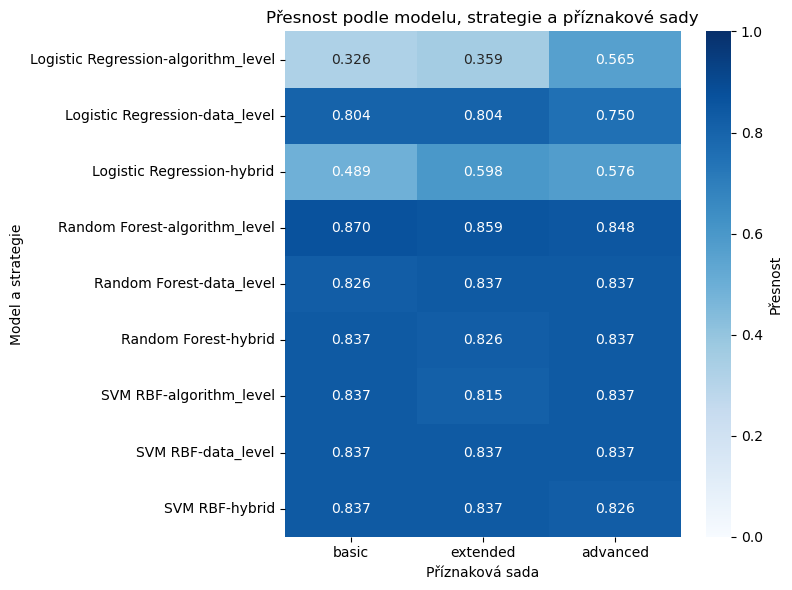

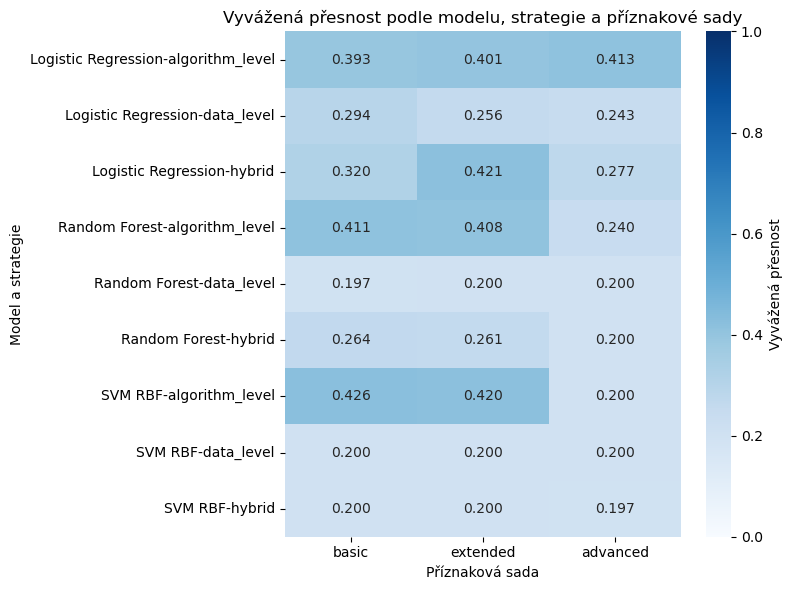

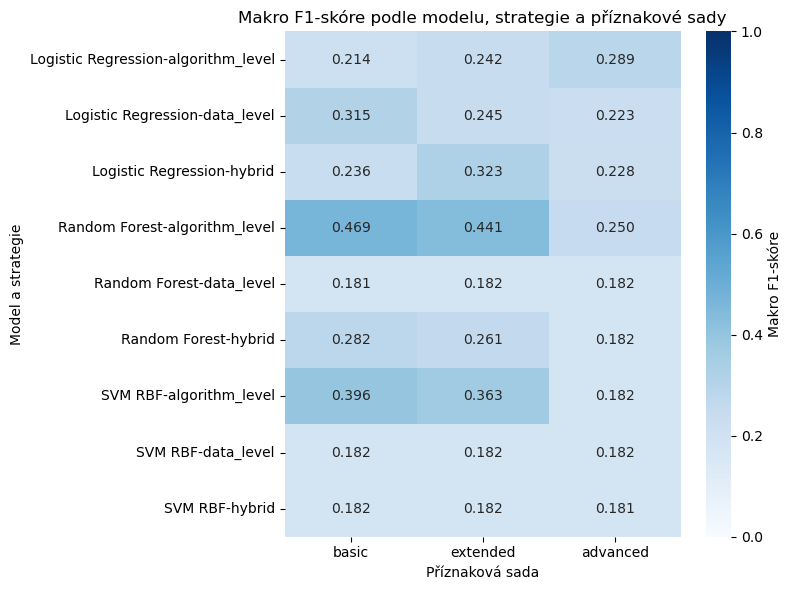

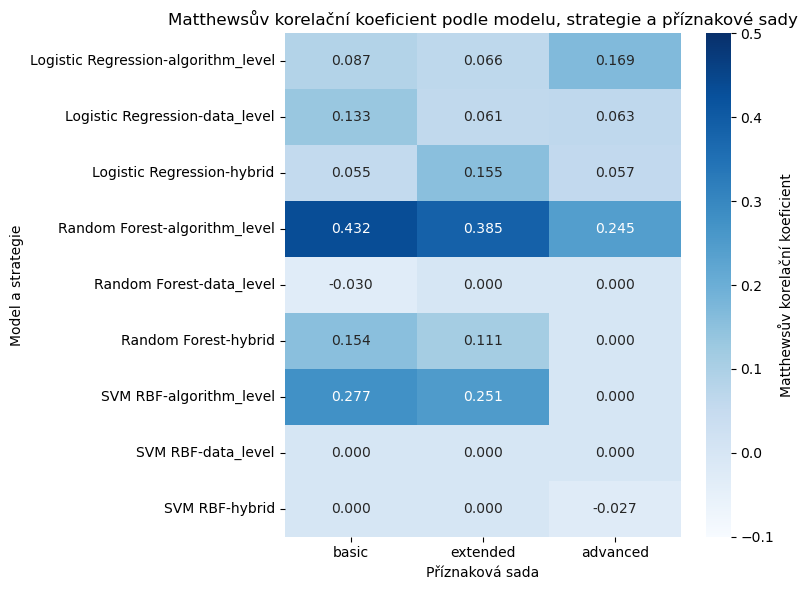

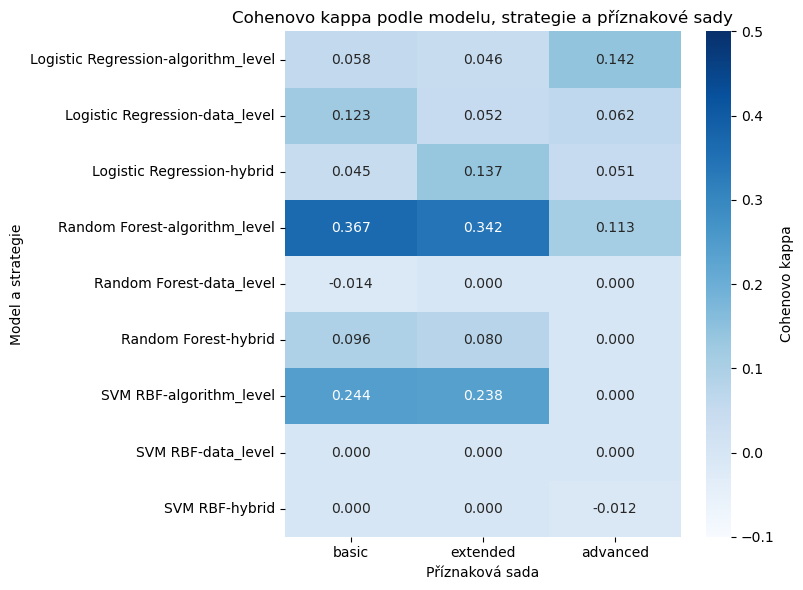

In [15]:
plot_heatmap("accuracy", "heatmap_accuracy.png", vmin=0, vmax=1)
plot_heatmap("balanced_accuracy", "heatmap_balanced_accuracy.png", vmin=0, vmax=1)
plot_heatmap("f1_macro", "heatmap_f1_macro.png", vmin=0, vmax=1)
plot_heatmap("mcc", "heatmap_mcc.png", vmin=-0.1, vmax=0.5)
plot_heatmap("kappa", "heatmap_kappa.png", vmin=-0.1, vmax=0.5)

## 5.9 Uložení vybraných modelů a porovnání jejich velikosti

V této části jsou uloženy modely pro vybranou konfiguraci Basic + algorithm-level. Tato konfigurace je použita pro orientační porovnání velikosti uložených modelů ve formátu `.joblib`. Cílem není uložit všechny natrénované modely, ale ukázat rozdíly v paměťové náročnosti jednotlivých algoritmů.

In [16]:
feature_set = "basic"
strategy = "algorithm_level"

train_df = datasets[(feature_set, strategy)]["train"]
test_df = datasets[(feature_set, strategy)]["test"]

feature_columns = get_feature_columns(train_df)

X_train = train_df[feature_columns]
y_train = train_df[TARGET_COLUMN]

X_test = test_df[feature_columns]
y_test = test_df[TARGET_COLUMN]

models_basic = get_models(strategy)

saved_models_info = []

for model_name, model in models_basic.items():
    model.fit(X_train, y_train)
    
    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("/", "_")
    )
    
    model_path = os.path.join(
        MODELS_DIR,
        f"{safe_name}_{feature_set}_{strategy}.joblib"
    )
    
    joblib.dump(model, model_path)
    
    size_kb = os.path.getsize(model_path) / 1024
    
    y_pred = model.predict(X_test)
    metrics = evaluate_model(y_test, y_pred)
    
    saved_models_info.append({
        "model": model_name,
        "feature_set": feature_set,
        "scenario": strategy,
        "path": model_path,
        "size_kb": size_kb,
        **metrics
    })

saved_models_df = pd.DataFrame(saved_models_info)
saved_models_df["size_kb"] = saved_models_df["size_kb"].round(2)

saved_models_df

,model,feature_set,scenario,path,size_kb,accuracy,balanced_accuracy,f1_macro,mcc,kappa
0,Logistic Regression,basic,algorithm_level,..\outputs\models\logistic_regression_basic_al...,3.70,0.326087,0.393074,0.213773,0.086872,0.057969
1,SVM RBF,basic,algorithm_level,..\outputs\models\svm_rbf_basic_algorithm_leve...,102.05,0.836957,0.425541,0.395881,0.277096,0.244250
2,Random Forest,basic,algorithm_level,..\outputs\models\random_forest_basic_algorith...,735.58,0.869565,0.410736,0.469175,0.432453,0.366972


In [17]:
model_size_table = saved_models_df[
    [
        "model",
        "feature_set",
        "scenario",
        "size_kb"
    ]
].copy()

model_size_table = model_size_table.rename(columns={
    "model": "Model",
    "feature_set": "Příznaková sada",
    "scenario": "Scénář",
    "size_kb": "Velikost (.joblib) [KB]"
})

model_size_table

,Model,Příznaková sada,Scénář,Velikost (.joblib) [KB]
0,Logistic Regression,basic,algorithm_level,3.70
1,SVM RBF,basic,algorithm_level,102.05
2,Random Forest,basic,algorithm_level,735.58


In [18]:
model_size_path = os.path.join(RESULTS_DIR, "model_sizes_basic_algorithm_level.csv")
model_size_table.to_csv(model_size_path, index=False, encoding="utf-8-sig")

print(f"Tabulka velikostí modelů byla uložena do: {model_size_path}")

Tabulka velikostí modelů byla uložena do: ..\outputs\results\model_sizes_basic_algorithm_level.csv


## 5.10 Detailní vyhodnocení vybrané konfigurace

Pro detailnější interpretaci je níže zobrazena matice záměn a klasifikační report pro konfiguraci Random Forest + Basic + algorithm-level. Tato konfigurace dosahuje nejvyšší celkové přesnosti, a proto je vhodná pro ukázku rozdílu mezi vysokou accuracy a omezenou schopností modelu rozlišovat minoritní třídy.

In [19]:
feature_set = "basic"
strategy = "algorithm_level"

train_df = datasets[(feature_set, strategy)]["train"]
test_df = datasets[(feature_set, strategy)]["test"]

feature_columns = get_feature_columns(train_df)

X_train = train_df[feature_columns]
y_train = train_df[TARGET_COLUMN]

X_test = test_df[feature_columns]
y_test = test_df[TARGET_COLUMN]

model = get_models(strategy)["Random Forest"]

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=PORADI_TRID_EN
)

cm_df = pd.DataFrame(
    cm,
    index=[TRIDA_MAP_CZ[label] for label in PORADI_TRID_EN],
    columns=[TRIDA_MAP_CZ[label] for label in PORADI_TRID_EN]
)

cm_df

,hlad,nepohodlí,únava,bolest břicha,říhání
hlad,76,1,0,0,0
nepohodlí,4,1,0,0,0
únava,4,0,1,0,0
bolest břicha,1,0,0,2,0
říhání,2,0,0,0,0


In [20]:
print(classification_report(
    y_test,
    y_pred,
    labels=PORADI_TRID_EN,
    target_names=[TRIDA_MAP_CZ[label] for label in PORADI_TRID_EN],
    zero_division=0
))

               precision    recall  f1-score   support

         hlad       0.87      0.99      0.93        77
    nepohodlí       0.50      0.20      0.29         5
        únava       1.00      0.20      0.33         5
bolest břicha       1.00      0.67      0.80         3
       říhání       0.00      0.00      0.00         2

     accuracy                           0.87        92
    macro avg       0.67      0.41      0.47        92
 weighted avg       0.85      0.87      0.84        92



## 5.11 Shrnutí výsledků a evaluace

V tomto notebooku bylo provedeno experimentální vyhodnocení klasifikačních modelů nad předzpracovanými daty vytvořenými v předchozí části práce. Celkem bylo otestováno 27 experimentálních konfigurací vzniklých kombinací tří klasifikačních algoritmů, tří strategií práce s třídní nevyvážeností a tří sad akustických příznaků.

Výsledky potvrzují, že samotná celková přesnost není pro hodnocení této úlohy dostačující. Některé modely dosahují vysoké hodnoty accuracy, avšak jejich balanced accuracy, macro F1-score, MCC nebo Cohenovo kappa ukazují omezenou schopnost rozlišovat minoritní třídy. To je patrné zejména u konfigurací, které mají tendenci predikovat převážně majoritní třídu hlad.

Čtyři z pěti sledovaných metrik (accuracy, macro F1-score, MCC a Cohenovo kappa) shodně označují jako nejlepší konfiguraci Random Forest se základní příznakovou sadou a strategií algorithm-level. Tato konfigurace dosahuje MCC = 0,433 a makro F1-skóre = 0,469, což v kontextu výrazně nevyváženého datasetu představuje statisticky smysluplný výsledek výrazně překračující úroveň náhodné klasifikace.

Detailní matice záměn pro tuto konfiguraci ukazuje, že model velmi dobře rozpoznává majoritní třídu hlad, ale jeho schopnost správně klasifikovat minoritní třídy zůstává omezená. Výsledky proto potvrzují komplexnost řešené úlohy a zároveň vymezují limity použitého datasetu i zvoleného přístupu založeného na agregovaných akustických příznacích.